In [1]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    cohen_kappa_score,
    classification_report,
    confusion_matrix
)

print("TensorFlow version:", tf.__version__)
print("Notebook environment is ready!")


TensorFlow version: 2.21.0
Notebook environment is ready!


In [2]:
# Reproducibility and common experiment settings
SEED = 42
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32
NUM_CLASSES = 5

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

CLASS_NAMES = [
    "No DR",
    "Mild",
    "Moderate",
    "Severe",
    "Proliferative DR"
]

print("Random seed:", SEED)
print("Image size:", IMAGE_SIZE)
print("Batch size:", BATCH_SIZE)
print("Number of classes:", NUM_CLASSES)
print("Classes:", CLASS_NAMES)

Random seed: 42
Image size: (224, 224)
Batch size: 32
Number of classes: 5
Classes: ['No DR', 'Mild', 'Moderate', 'Severe', 'Proliferative DR']


In [3]:
from pathlib import Path

# Find the project root automatically
PROJECT_ROOT = Path.cwd()

if not (PROJECT_ROOT / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data" / "aptos2019-blindness-detection"
TRAIN_CSV = DATA_DIR / "train.csv"
TRAIN_IMAGES_DIR = DATA_DIR / "train_images"

print("Project root:", PROJECT_ROOT)
print("Dataset folder exists:", DATA_DIR.exists())
print("train.csv exists:", TRAIN_CSV.exists())
print("train_images folder exists:", TRAIN_IMAGES_DIR.exists())
print("Number of training images:", len(list(TRAIN_IMAGES_DIR.glob("*.png"))))

Project root: c:\Users\MSI\Desktop\DL-Blindness-ditect\Deep-Learning-Assignment-Group-ID-5
Dataset folder exists: True
train.csv exists: True
train_images folder exists: True
Number of training images: 3662


In [4]:
# Load the APTOS training labels
df = pd.read_csv(TRAIN_CSV)

print("Dataset shape:", df.shape)
print("\nColumn names:", df.columns.tolist())
print("\nMissing values:")
print(df.isnull().sum())

print("\nClass distribution:")
print(df["diagnosis"].value_counts().sort_index())

df.head()

Dataset shape: (3662, 2)

Column names: ['id_code', 'diagnosis']

Missing values:
id_code      0
diagnosis    0
dtype: int64

Class distribution:
diagnosis
0    1805
1     370
2     999
3     193
4     295
Name: count, dtype: int64


,id_code,diagnosis
0,000c1434d8d7,2
1,001639a390f0,4
2,0024cdab0c1e,1
3,002c21358ce6,0
4,005b95c28852,0


In [5]:
# Add the complete image path for every row
df["image_path"] = df["id_code"].apply(
    lambda image_id: str(TRAIN_IMAGES_DIR / f"{image_id}.png")
)

# Check whether every referenced image exists
df["image_exists"] = df["image_path"].apply(os.path.exists)

print("Total CSV records:", len(df))
print("Images found:", df["image_exists"].sum())
print("Missing images:", (~df["image_exists"]).sum())

df[["id_code", "diagnosis", "image_path"]].head()

Total CSV records: 3662
Images found: 3662
Missing images: 0


,id_code,diagnosis,image_path
0,000c1434d8d7,2,c:\Users\MSI\Desktop\DL-Blindness-ditect\Deep-...
1,001639a390f0,4,c:\Users\MSI\Desktop\DL-Blindness-ditect\Deep-...
2,0024cdab0c1e,1,c:\Users\MSI\Desktop\DL-Blindness-ditect\Deep-...
3,002c21358ce6,0,c:\Users\MSI\Desktop\DL-Blindness-ditect\Deep-...
4,005b95c28852,0,c:\Users\MSI\Desktop\DL-Blindness-ditect\Deep-...


In [6]:
# First split: 70% training and 30% temporary data
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    random_state=SEED,
    stratify=df["diagnosis"]
)

# Second split: divide temporary data equally into validation and test sets
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=SEED,
    stratify=temp_df["diagnosis"]
)

# Reset row indexes
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Total images:", len(df))
print("Training images:", len(train_df))
print("Validation images:", len(val_df))
print("Test images:", len(test_df))

print("\nTraining class distribution:")
print(train_df["diagnosis"].value_counts().sort_index())

print("\nValidation class distribution:")
print(val_df["diagnosis"].value_counts().sort_index())

print("\nTest class distribution:")
print(test_df["diagnosis"].value_counts().sort_index())

Total images: 3662
Training images: 2563
Validation images: 549
Test images: 550

Training class distribution:
diagnosis
0    1263
1     259
2     699
3     135
4     207
Name: count, dtype: int64

Validation class distribution:
diagnosis
0    271
1     55
2    150
3     29
4     44
Name: count, dtype: int64

Test class distribution:
diagnosis
0    271
1     56
2    150
3     29
4     44
Name: count, dtype: int64


In [7]:
# Save the fixed data splits for fair model comparison
SPLITS_DIR = PROJECT_ROOT / "data" / "splits"
SPLITS_DIR.mkdir(parents=True, exist_ok=True)

columns_to_save = ["id_code", "diagnosis"]

train_df[columns_to_save].to_csv(
    SPLITS_DIR / "train_split.csv",
    index=False
)

val_df[columns_to_save].to_csv(
    SPLITS_DIR / "val_split.csv",
    index=False
)

test_df[columns_to_save].to_csv(
    SPLITS_DIR / "test_split.csv",
    index=False
)

print("Split files saved in:", SPLITS_DIR)
print("train_split.csv:", (SPLITS_DIR / "train_split.csv").exists())
print("val_split.csv:", (SPLITS_DIR / "val_split.csv").exists())
print("test_split.csv:", (SPLITS_DIR / "test_split.csv").exists())

Split files saved in: c:\Users\MSI\Desktop\DL-Blindness-ditect\Deep-Learning-Assignment-Group-ID-5\data\splits
train_split.csv: True
val_split.csv: True
test_split.csv: True


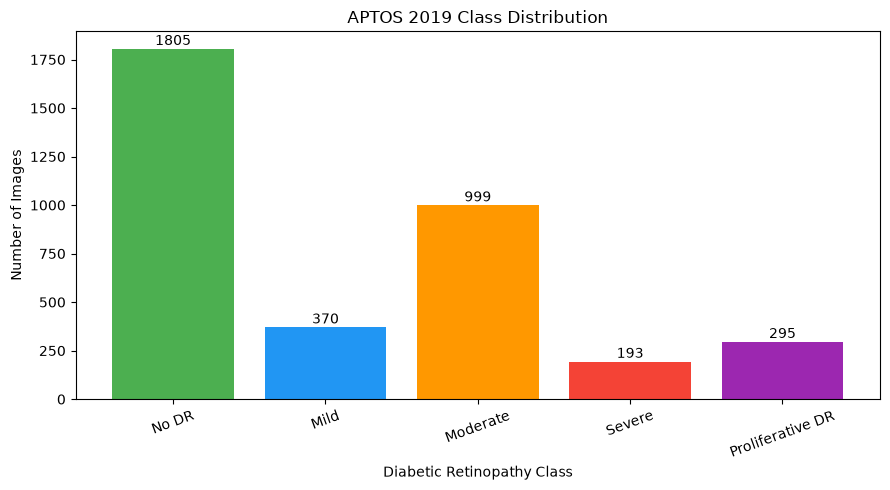

In [8]:
# Visualize the class distribution in the complete labelled dataset
class_counts = df["diagnosis"].value_counts().sort_index()

plt.figure(figsize=(9, 5))

bars = plt.bar(
    CLASS_NAMES,
    class_counts.values,
    color=["#4CAF50", "#2196F3", "#FF9800", "#F44336", "#9C27B0"]
)

plt.title("APTOS 2019 Class Distribution")
plt.xlabel("Diabetic Retinopathy Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=20)

for bar, count in zip(bars, class_counts.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 20,
        str(count),
        ha="center"
    )

plt.tight_layout()
plt.show()

In [9]:
# Calculate class weights using only the training set
class_labels = np.sort(train_df["diagnosis"].unique())

weights = compute_class_weight(
    class_weight="balanced",
    classes=class_labels,
    y=train_df["diagnosis"]
)

class_weights = {
    int(label): float(weight)
    for label, weight in zip(class_labels, weights)
}

print("Class weights:")
for label, weight in class_weights.items():
    print(f"{label} - {CLASS_NAMES[label]}: {weight:.4f}")

Class weights:
0 - No DR: 0.4059
1 - Mild: 1.9792
2 - Moderate: 0.7333
3 - Severe: 3.7970
4 - Proliferative DR: 2.4763


In [10]:
# Function to read and resize one image
def load_image(image_path, label):
    image = tf.io.read_file(image_path)
    image = tf.image.decode_png(image, channels=3)
    image = tf.image.resize(image, IMAGE_SIZE)
    image = tf.cast(image, tf.float32)

    return image, label


# Function to create a TensorFlow dataset
def create_dataset(dataframe, training=False):
    image_paths = dataframe["image_path"].values
    labels = dataframe["diagnosis"].values.astype(np.int32)

    dataset = tf.data.Dataset.from_tensor_slices((image_paths, labels))

    if training:
        dataset = dataset.shuffle(
            buffer_size=len(dataframe),
            seed=SEED,
            reshuffle_each_iteration=True
        )

    dataset = dataset.map(
        load_image,
        num_parallel_calls=tf.data.AUTOTUNE
    )

    dataset = dataset.batch(BATCH_SIZE)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)

    return dataset


train_dataset = create_dataset(train_df, training=True)
val_dataset = create_dataset(val_df)
test_dataset = create_dataset(test_df)

# Check one training batch
images, labels = next(iter(train_dataset))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("Image data type:", images.dtype)
print("First batch labels:", labels.numpy())

Image batch shape: (32, 224, 224, 3)
Label batch shape: (32,)
Image data type: <dtype: 'float32'>
First batch labels: [0 0 4 2 2 2 0 2 0 0 2 0 2 0 4 0 2 1 3 4 0 2 0 0 0 0 4 2 4 2 0 0]


In [11]:
# Core augmentation policy used only during training
data_augmentation = tf.keras.Sequential(
    [
        tf.keras.layers.RandomFlip(
            mode="horizontal",
            seed=SEED
        ),
        tf.keras.layers.RandomRotation(
            factor=0.05,
            fill_mode="reflect",
            seed=SEED
        ),
        tf.keras.layers.RandomZoom(
            height_factor=0.10,
            width_factor=0.10,
            fill_mode="reflect",
            seed=SEED
        ),
        tf.keras.layers.RandomContrast(
            factor=0.10,
            seed=SEED
        )
    ],
    name="data_augmentation"
)

# Test the augmentation using the current image batch
augmented_images = data_augmentation(images, training=True)

print("Original batch shape:", images.shape)
print("Augmented batch shape:", augmented_images.shape)
print("Augmentation policy created successfully!")

Original batch shape: (32, 224, 224, 3)
Augmented batch shape: (32, 224, 224, 3)
Augmentation policy created successfully!


In [12]:
# Load ResNet50 with ImageNet pretrained weights
base_model = tf.keras.applications.ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], 3)
)

# Freeze all pretrained ResNet50 layers initially
base_model.trainable = False

# Build the new APTOS 5-class model
inputs = tf.keras.Input(
    shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], 3),
    name="input_image"
)

x = data_augmentation(inputs)
x = tf.keras.applications.resnet50.preprocess_input(x)
x = base_model(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D(name="global_average_pooling")(x)
x = tf.keras.layers.Dropout(0.40, name="dropout")(x)

outputs = tf.keras.layers.Dense(
    NUM_CLASSES,
    activation="softmax",
    name="classification_output"
)(x)

model = tf.keras.Model(
    inputs=inputs,
    outputs=outputs,
    name="APTOS_ResNet50"
)

print("Model name:", model.name)
print("Total parameters:", f"{model.count_params():,}")
print("ResNet50 base trainable:", base_model.trainable)
print("Output shape:", model.output_shape)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 437s 5us/step
Model name: APTOS_ResNet50
Total parameters: 23,597,957
ResNet50 base trainable: False
Output shape: (None, 5)


In [13]:
# Compile Stage 1: train only the new classification head
INITIAL_LEARNING_RATE = 1e-3

model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=INITIAL_LEARNING_RATE
    ),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=[
        tf.keras.metrics.SparseCategoricalAccuracy(
            name="accuracy"
        )
    ]
)

print("Model compiled successfully!")
print("Optimizer: Adam")
print("Initial learning rate:", INITIAL_LEARNING_RATE)
print("Loss: Sparse Categorical Crossentropy")

Model compiled successfully!
Optimizer: Adam
Initial learning rate: 0.001
Loss: Sparse Categorical Crossentropy


In [14]:
# Training budget
STAGE1_EPOCHS = 10
STAGE2_EPOCHS = 15
EARLY_STOPPING_PATIENCE = 5

# Folder for ResNet50 outputs
RESULTS_DIR = PROJECT_ROOT / "results" / "resnet50"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Stage 1 callbacks
stage1_callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=EARLY_STOPPING_PATIENCE,
        restore_best_weights=True,
        verbose=1
    ),

    tf.keras.callbacks.ModelCheckpoint(
        filepath=str(RESULTS_DIR / "best_resnet50_stage1.keras"),
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=2,
        min_lr=1e-6,
        verbose=1
    )
]

print("Stage 1 maximum epochs:", STAGE1_EPOCHS)
print("Stage 2 maximum epochs:", STAGE2_EPOCHS)
print("Total maximum training budget:", STAGE1_EPOCHS + STAGE2_EPOCHS)
print("Early-stopping patience:", EARLY_STOPPING_PATIENCE)
print("Results folder:", RESULTS_DIR)

Stage 1 maximum epochs: 10
Stage 2 maximum epochs: 15
Total maximum training budget: 25
Early-stopping patience: 5
Results folder: c:\Users\MSI\Desktop\DL-Blindness-ditect\Deep-Learning-Assignment-Group-ID-5\results\resnet50
